# AOMIC-ID1000 - Automated Ontology and Tiered Results

This notebook shows the automated data understanding that grounds the ontology, the
resulting ontology graph, how well the semantic ontology matches the data-driven
clusters, the complexity-tier ladder, and per-tier engine performance.

For hands-on exploration, open `../ontology/ontology_viewer.html` in a browser: an
interactive tree with expand/collapse, drag, and top-down / left-right / radial layouts.

In [1]:
import json, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
ROOT = Path.cwd().parent
IND = "#6366f1"; GRN = "#10b981"; ORG = "#f59e0b"; RED = "#ef4444"; BLU = "#38bdf8"

def _leaves(node):
    ch = node.get("children")
    if not ch:
        return [node]
    out = []
    for c in ch:
        out += _leaves(c)
    return out

def n_leaves(node):
    return len(_leaves(node))

def mm_leaves(node, out):
    # Collect every _leaves record from an arbitrary-depth multimodal tree.
    if isinstance(node, dict):
        for k, v in node.items():
            if k == "_leaves":
                out.extend(v)
            elif isinstance(v, dict):
                mm_leaves(v, out)

import networkx as nx
onto = json.load(open(ROOT / "ontology" / "subclass_structure.json"))
explore = json.load(open(ROOT / "ontology" / "exploration_report.json"))
report = json.load(open(ROOT / "ontology" / "ontology_report.json"))
tiers = json.load(open(ROOT / "results" / "tiers_summary.json"))["tiers"]
print("domains:", len(onto["domains"]), "| ARI ontology vs clusters:",
      report.get("cluster_agreement",{}).get("adjusted_rand_index"))

domains: 4 | ARI ontology vs clusters: 0.07


## 1. The ontology as a graph
The ontology is now arbitrary-depth. This view shows ROOT -> domain -> first-level child; the Brain domain expands into Morphometry and Connectomics, which themselves hold deeper region/network structure (node size = number of leaf features).

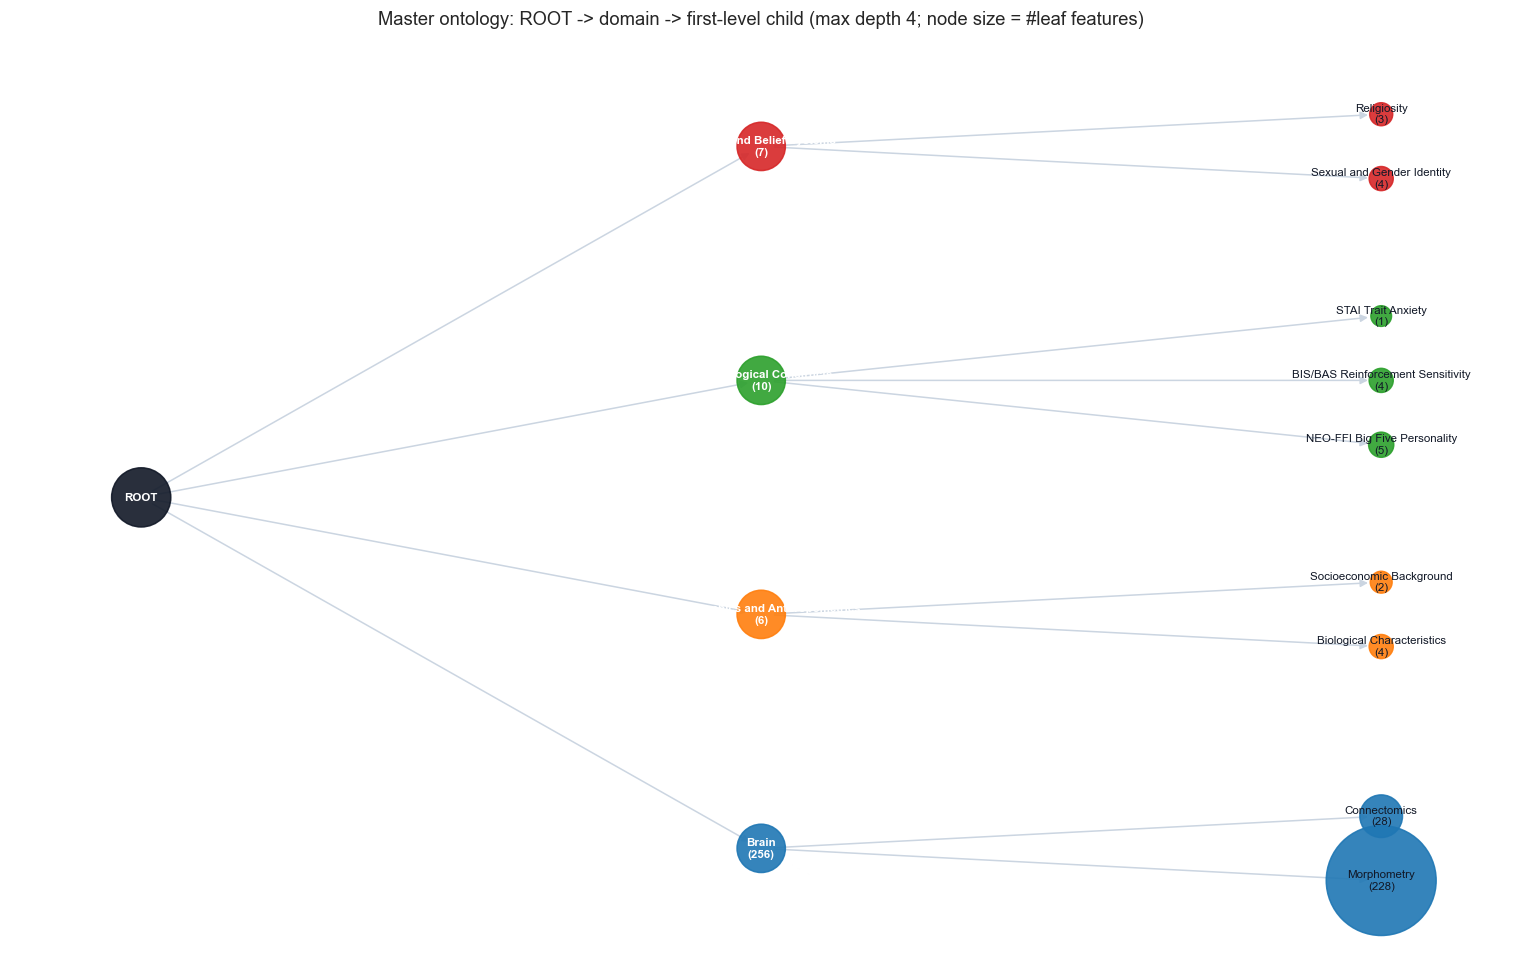

In [2]:
depth = lambda node: 0 if not node.get("children") else 1+max(depth(c) for c in node["children"])
G = nx.DiGraph(); pos = {}; sizes=[]; colors=[]; labels={}
palette = sns.color_palette("tab10", len(onto["domains"]))
G.add_node("ROOT"); pos["ROOT"]=(0,0); sizes.append(1500); colors.append("#111827"); labels["ROOT"]="ROOT"
ndom = len(onto["domains"])
for di,d in enumerate(onto["domains"]):
    dy = (di-(ndom-1)/2)*4
    G.add_node(d["id"]); G.add_edge("ROOT", d["id"]); pos[d["id"]]=(1,dy)
    sizes.append(1000); colors.append(palette[di]); labels[d["id"]]=f"{d['label']}\n({n_leaves(d)})"
    kids=d.get("children",[]); ns=len(kids)
    for si,s in enumerate(kids):
        sid=f"{d['id']}/{s['id']}"; sy=dy+(si-(ns-1)/2)*1.1
        G.add_node(sid); G.add_edge(d["id"], sid); pos[sid]=(2, sy)
        sizes.append(160+22*n_leaves(s)); colors.append(palette[di]); labels[sid]=f"{s['label']}\n({n_leaves(s)})"
fig, ax = plt.subplots(figsize=(14, 9))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#cbd5e1")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color=colors, alpha=0.9)
for n,(x,y) in pos.items():
    ax.text(x, y, labels.get(n,n), fontsize=7.5, ha="center", va="center",
            color="white" if x<2 else "#111827", fontweight="bold" if x<2 else "normal")
maxdepth = max(depth(d) for d in onto["domains"])
ax.set_title(f"Master ontology: ROOT -> domain -> first-level child (max depth {maxdepth}; node size = #leaf features)"); ax.axis("off")
plt.tight_layout(); plt.show()

## 2. Feature counts and data-driven clusters

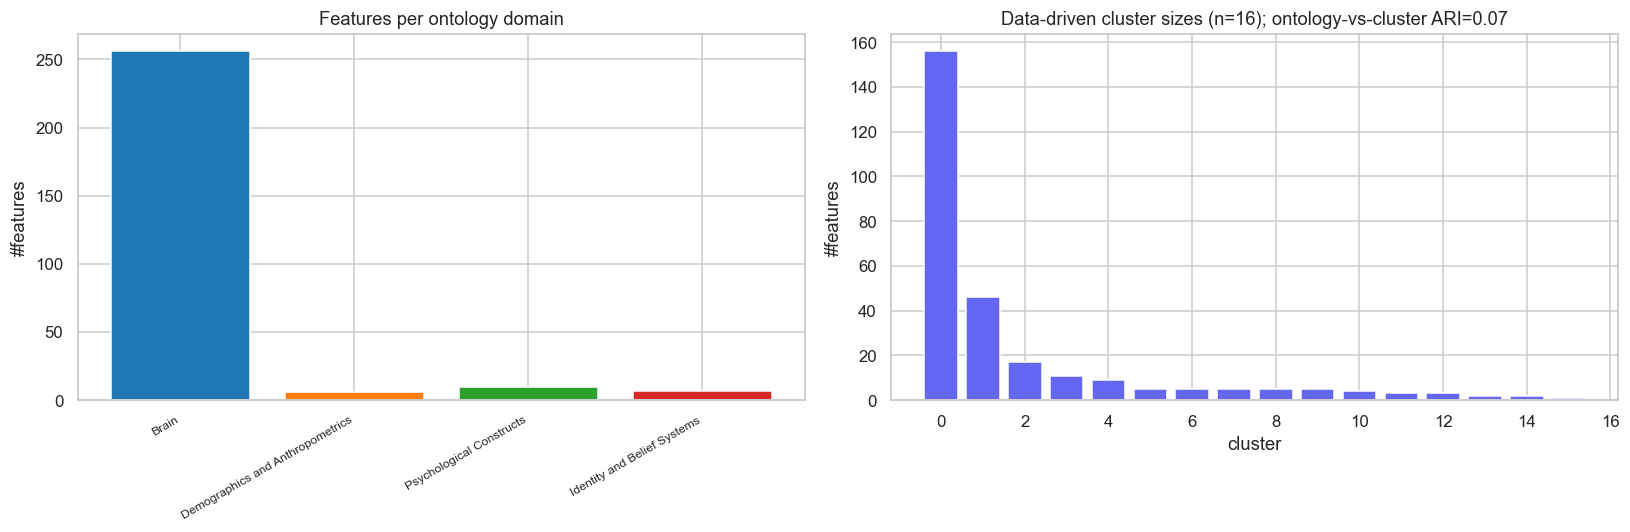

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
dom_counts = {d["label"]: n_leaves(d) for d in onto["domains"]}
ax[0].bar(range(len(dom_counts)), list(dom_counts.values()),
          color=sns.color_palette("tab10", len(dom_counts)))
ax[0].set_xticks(range(len(dom_counts))); ax[0].set_xticklabels(list(dom_counts), rotation=30, ha="right", fontsize=8)
ax[0].set(title="Features per ontology domain", ylabel="#features")
csz = sorted((len(v) for v in explore["auto_clusters"].values()), reverse=True)
ax[1].bar(range(len(csz)), csz, color=IND)
ari = report.get("cluster_agreement",{}).get("adjusted_rand_index")
ax[1].set(title=f"Data-driven cluster sizes (n={len(csz)}); ontology-vs-cluster ARI={ari}",
          xlabel="cluster", ylabel="#features")
plt.tight_layout(); plt.show()

The adjusted Rand index compares the LLM's semantic subdomains against purely statistical clusters. Moderate agreement is expected and healthy: constructs like the Big Five are grouped by meaning even when they are not the tightest statistical cluster, while genuine redundancies below are grouped by both.

## 3. Redundancy detected by exploration

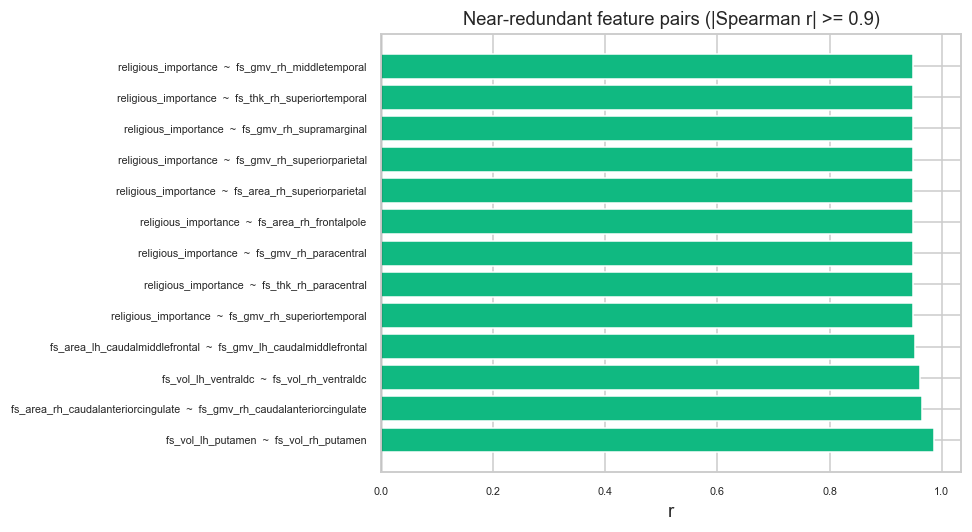

In [4]:
rp = pd.DataFrame(explore["redundant_pairs"])
if len(rp):
    rp["pair"] = rp["a"]+"  ~  "+rp["b"]
    rp = rp.reindex(rp["spearman_r"].abs().sort_values(ascending=False).index).head(13)
    fig, ax = plt.subplots(figsize=(9,5))
    ax.barh(rp["pair"], rp["spearman_r"], color=[RED if v<0 else GRN for v in rp["spearman_r"]])
    ax.axvline(0,color="#333"); ax.set(title="Near-redundant feature pairs (|Spearman r| >= 0.9)", xlabel="r")
    ax.tick_params(labelsize=7); plt.tight_layout(); plt.show()

## 4. Complexity tier ladder and per-tier performance
**This is the headline result: the full 100-subject evaluation batch** (74-person common-success intersection across all nine tiers), loaded from `results/tiers_summary.json`. It is not the two-subject demo below. The feature counts shown are the earlier structure the batch was run on; the upgraded 279-feature high-resolution structure (sections 1-2) has not been re-run at full batch scale.

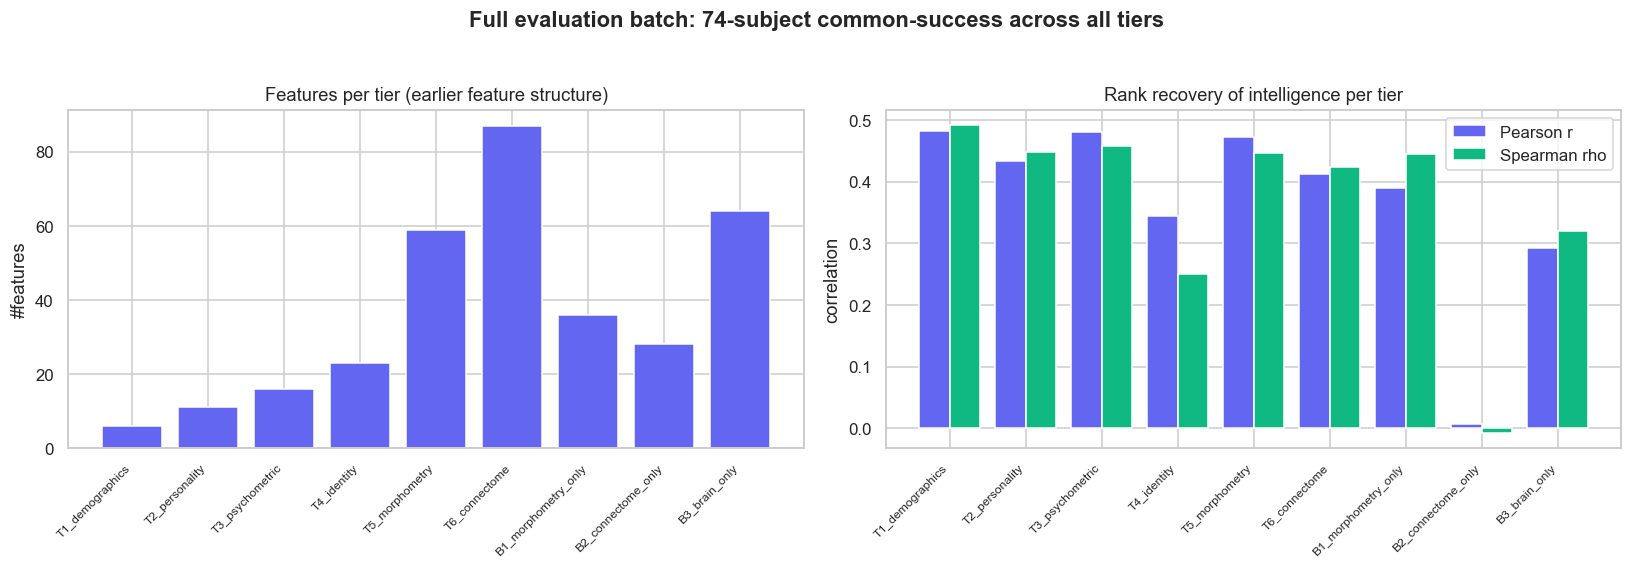

In [5]:
td = pd.DataFrame(tiers)
n_common = json.load(open(ROOT/"results"/"tiers_summary.json"))["evaluation"]["common_success_n"]
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].bar(td["tier"], td["n_features"], color=IND)
ax[0].set_xticklabels(td["tier"], rotation=45, ha="right", fontsize=8)
ax[0].set(title="Features per tier (earlier feature structure)", ylabel="#features")
x = np.arange(len(td)); w=0.4
ax[1].bar(x-w/2, td["pearson_r"], w, label="Pearson r", color=IND)
ax[1].bar(x+w/2, td["spearman_rho"], w, label="Spearman rho", color=GRN)
ax[1].set_xticks(x); ax[1].set_xticklabels(td["tier"], rotation=45, ha="right", fontsize=8)
ax[1].set(title="Rank recovery of intelligence per tier", ylabel="correlation"); ax[1].legend()
fig.suptitle(f"Full evaluation batch: {n_common}-subject common-success across all tiers", y=1.03, fontweight="bold")
plt.tight_layout(); plt.show()

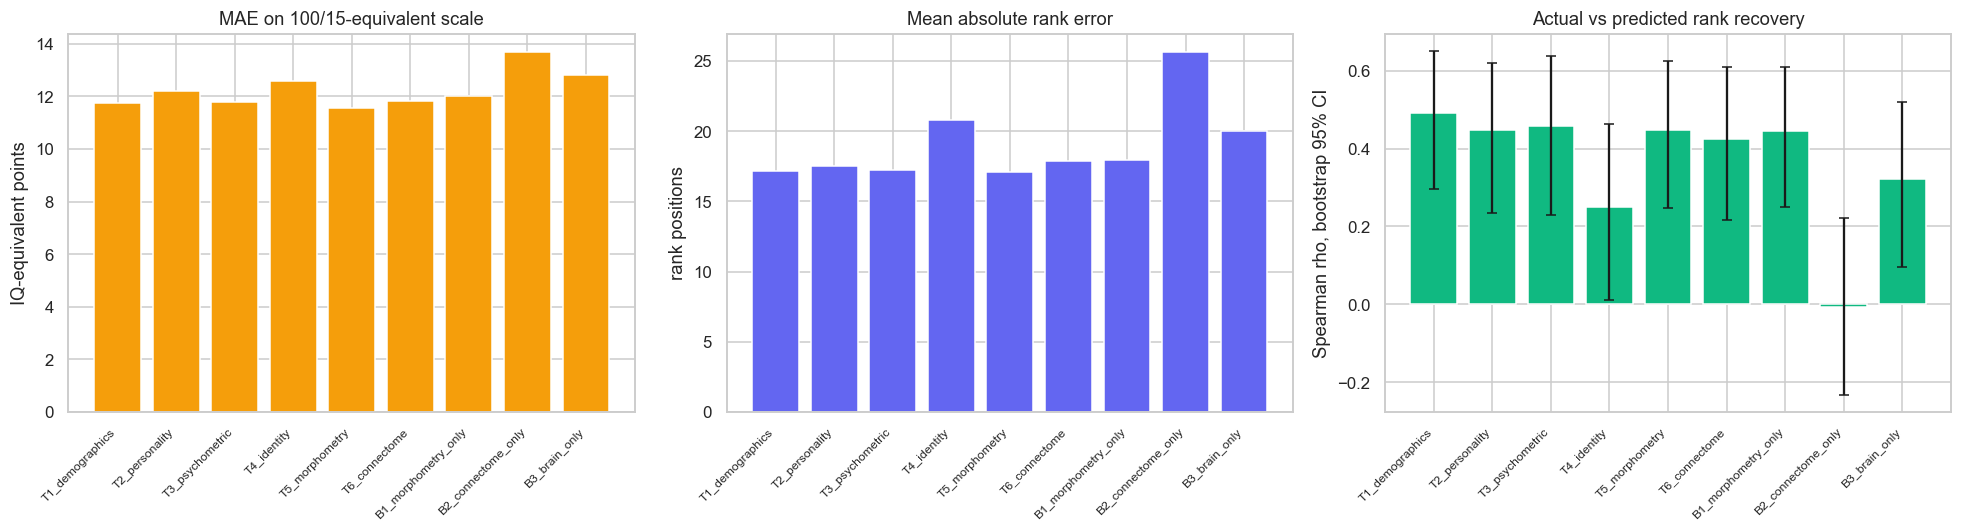

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].bar(x, td["mae_iq15_equivalent"], color=ORG)
ax[0].set_xticks(x); ax[0].set_xticklabels(td["tier"], rotation=45, ha="right", fontsize=8)
ax[0].set(title="MAE on 100/15-equivalent scale", ylabel="IQ-equivalent points")
ax[1].bar(x, td["rank_mae_positions"], color=IND)
ax[1].set_xticks(x); ax[1].set_xticklabels(td["tier"], rotation=45, ha="right", fontsize=8)
ax[1].set(title="Mean absolute rank error", ylabel="rank positions")
ci = np.array(td["spearman_bootstrap_ci95"].tolist(), dtype=float)
rho = td["spearman_rho"].to_numpy(float)
yerr = np.vstack([rho-ci[:,0], ci[:,1]-rho])
ax[2].bar(x, rho, yerr=yerr, color=GRN, capsize=3)
ax[2].set_xticks(x); ax[2].set_xticklabels(td["tier"], rotation=45, ha="right", fontsize=8)
ax[2].set(title="Actual vs predicted rank recovery", ylabel="Spearman rho, bootstrap 95% CI")
plt.tight_layout(); plt.show()

## 5. One participant as the engine sees it

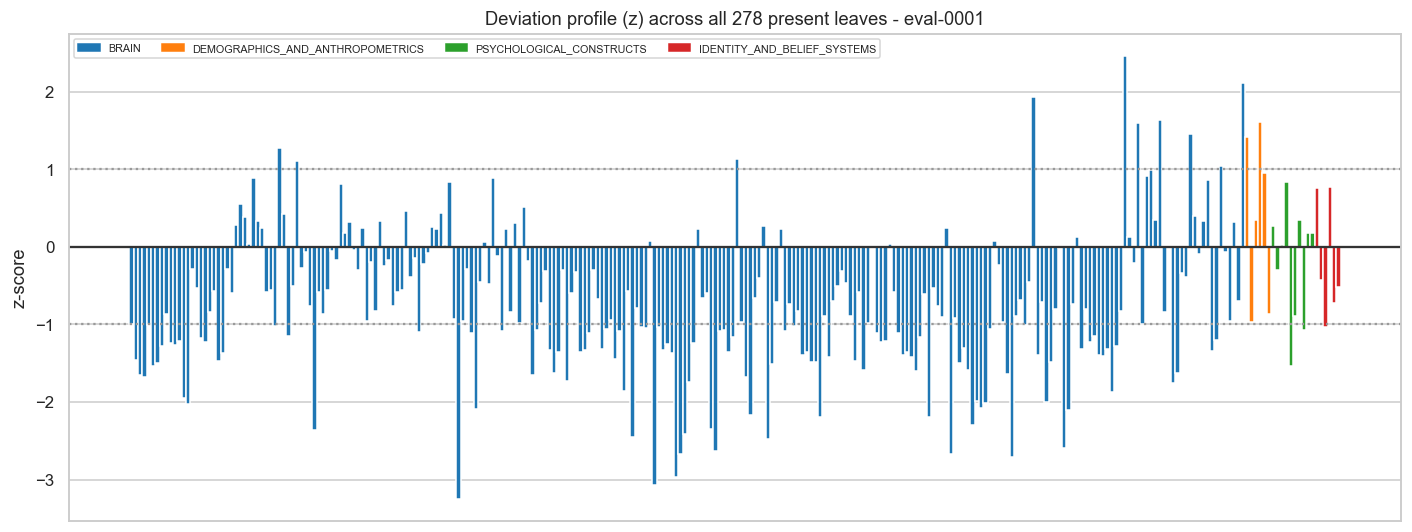

In [7]:
import glob
tdir = sorted(glob.glob(str(ROOT/"compass_inputs"/"T6_connectome"/"eval-*")))[0]
mm = json.load(open(Path(tdir)/"multimodal_data.json"))
rows=[]
for dom, tree in mm.items():          # arbitrary-depth: collect leaves recursively per domain
    leaves=[]; mm_leaves(tree, leaves)
    for leaf in leaves:
        if leaf.get("z_score") is not None:
            rows.append({"domain":dom, "feature":leaf["feature"], "z":leaf["z_score"]})
zz = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(13,5))
palette = dict(zip(zz["domain"].unique(), sns.color_palette("tab10", zz["domain"].nunique())))
ax.bar(range(len(zz)), zz["z"], color=[palette[d] for d in zz["domain"]], width=1.0)
ax.axhline(0,color="#333"); ax.axhline(1,color="#999",ls=":"); ax.axhline(-1,color="#999",ls=":")
ax.set(title=f"Deviation profile (z) across all {len(zz)} present leaves - {Path(tdir).name}", ylabel="z-score")
ax.set_xticks([])
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=d) for d,c in palette.items()], fontsize=7, ncol=4)
plt.tight_layout(); plt.show()

Every tier is a filtered projection of this one ontology, so the engine always receives a clean, non-redundant hierarchy at full depth; only the set of present leaf values changes. The full-tier profile above spans 279 leaves (256 brain + 23 self-report).

## 6. Hierarchical IST prediction on a diverse 10-subject cohort (all tiers)
The engine now runs in **hierarchical mixed-task** mode: it predicts total intelligence (root, univariate regression) and the three IST subscales fluid / memory / crystallised (child, multivariate regression) together, on the upgraded 279-feature structure. The three subscales are outputs only, never predictors, so there is no leakage. This is a diverse 10-subject cohort (total IST spanning about 87 to 280) run across every tier. n=10 is illustrative, not the quantitative benchmark (that is the 100-subject batch in section 4).

78 complete hierarchical runs; spend this run: $2.3868


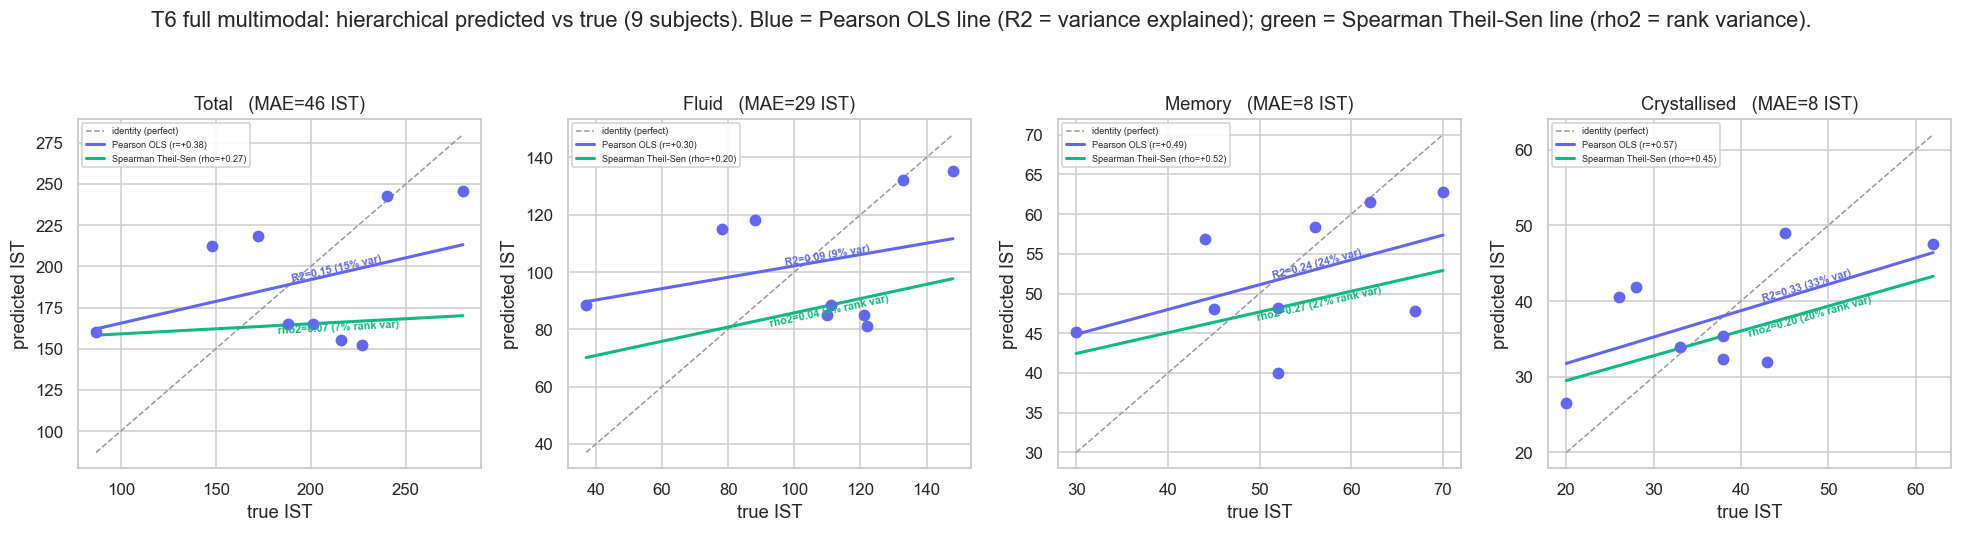

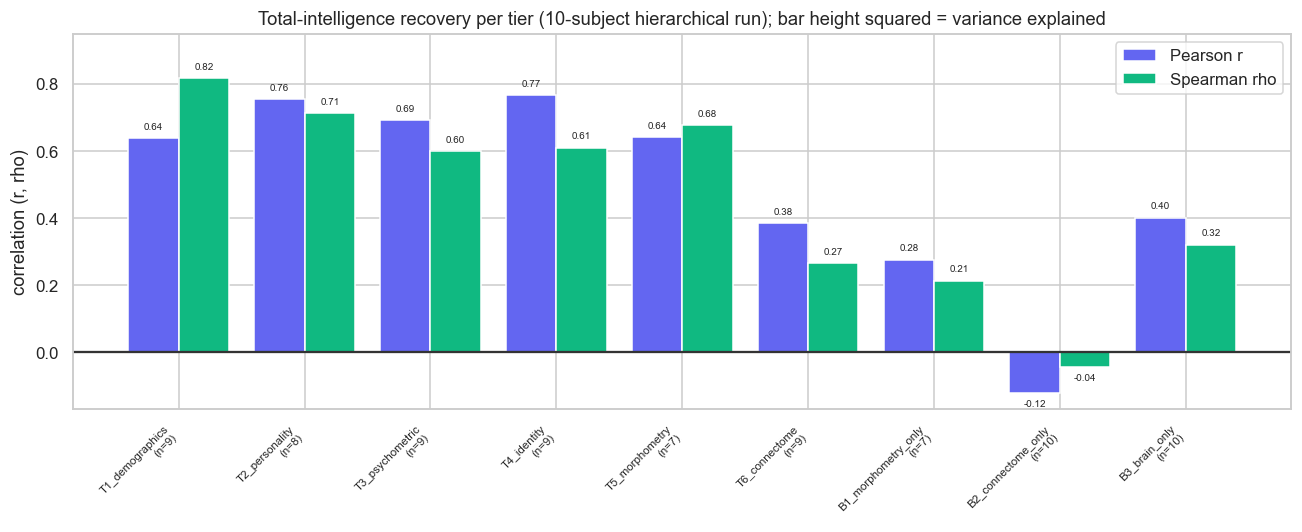

In [8]:
from scipy.stats import spearmanr, pearsonr, theilslopes
h = json.load(open(ROOT/"results"/"hierarchical_10subject"/"predictions.json"))
outputs = h["outputs"]
gt = {c["participant_id"]: c["ground_truth_all"] for c in h["cohort"]}
rows = [r for r in h["predictions"] if r.get("predicted") and not r.get("missing_outputs")]
dfp = pd.DataFrame([dict(tier=r["tier"], pid=r["participant_id"],
                         **{f"pred_{o}": r["predicted"][o] for o in outputs},
                         **{f"true_{o}": gt[r["participant_id"]][o] for o in outputs}) for r in rows])
print(f"{len(rows)} complete hierarchical runs; spend this run: ${h.get('usd_spent')}")

for c in dfp.columns:
    if c.startswith(("true_","pred_")): dfp[c] = pd.to_numeric(dfp[c], errors="coerce")

# Panel A: full multimodal tier (T6) predicted vs truth for all four IST outputs.
# Each scatter carries the identity line plus TWO fitted lines: the Pearson line
# (ordinary least squares, sensitive to magnitude) and the Spearman line
# (Theil-Sen, the rank-based robust slope that tracks monotonic association).
full = dfp[dfp["tier"]=="T6_connectome"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
titles = {"IST_intelligence_total":"Total","IST_fluid":"Fluid","IST_memory":"Memory","IST_crystallised":"Crystallised"}
_labels = []   # (ax, xe, intercept, slope, colour, text, side) for post-layout rotated labels
for ax,o in zip(axes, outputs):
    pair = full[[f"true_{o}", f"pred_{o}"]].dropna()
    xt, yp = pair[f"true_{o}"].values, pair[f"pred_{o}"].values
    ax.scatter(xt, yp, color=IND, s=45, zorder=3)
    mae = float(np.mean(np.abs(yp - xt))) if len(pair) else float("nan")
    if len(pair) > 2:
        r = pearsonr(xt, yp)[0]; rho = spearmanr(xt, yp).statistic
        lims=[min(xt.min(),yp.min()), max(xt.max(),yp.max())]
        ax.plot(lims, lims, color="#999", ls="--", lw=1, label="identity (perfect)", zorder=1)
        xs = np.linspace(xt.min(), xt.max(), 50)
        b1, b0 = np.polyfit(xt, yp, 1)
        ax.plot(xs, b0 + b1*xs, color=IND, lw=2, zorder=2, label=f"Pearson OLS (r={r:+.2f})")
        sl, ic, _, _ = theilslopes(yp, xt)
        ax.plot(xs, ic + sl*xs, color=GRN, lw=2, zorder=2, label=f"Spearman Theil-Sen (rho={rho:+.2f})")
        ax.legend(fontsize=6, loc="upper left", framealpha=0.9)
        xe = xt.min() + 0.66*(xt.max()-xt.min())
        _labels.append((ax, xe, b0, b1, IND, f"R2={r**2:.2f} ({r**2*100:.0f}% var)", "above"))
        _labels.append((ax, xe, ic, sl, GRN, f"rho2={rho**2:.2f} ({rho**2*100:.0f}% rank var)", "below"))
    ax.set(title=f"{titles.get(o,o)}   (MAE={mae:.0f} IST)", xlabel="true IST", ylabel="predicted IST")
plt.suptitle(f"T6 full multimodal: hierarchical predicted vs true ({len(full)} subjects). "
             f"Blue = Pearson OLS line (R2 = variance explained); green = Spearman Theil-Sen line (rho2 = rank variance).", y=1.05)
plt.tight_layout()
# Write the explained-variance label along each line, rotated to the line's on-screen angle
# (computed after layout so the axes aspect ratio is final).
for ax, xe, b0_, b1_, col, txt, side in _labels:
    dx = 0.08*(ax.get_xlim()[1]-ax.get_xlim()[0])
    p0 = ax.transData.transform((xe-dx, b0_+b1_*(xe-dx)))
    p1 = ax.transData.transform((xe+dx, b0_+b1_*(xe+dx)))
    ang = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
    ax.text(xe, b0_+b1_*xe, txt, color=col, fontsize=7, fontweight="bold",
            ha="center", va="bottom" if side=="above" else "top",
            rotation=ang, rotation_mode="anchor")
plt.show()

# Panel B: per-tier rank recovery of the total across the 10-subject hierarchical run
tier_order = [t for t in ["T1_demographics","T2_personality","T3_psychometric","T4_identity",
              "T5_morphometry","T6_connectome","B1_morphometry_only","B2_connectome_only","B3_brain_only"]
              if t in dfp["tier"].unique()]
tcol = outputs[0]
pear, spear, ns = [], [], []
for t in tier_order:
    g = dfp[dfp["tier"]==t][[f"true_{tcol}", f"pred_{tcol}"]].dropna()
    ns.append(len(g))
    if len(g) > 2:
        pear.append(pearsonr(g[f"true_{tcol}"], g[f"pred_{tcol}"])[0])
        spear.append(spearmanr(g[f"true_{tcol}"], g[f"pred_{tcol}"]).statistic)
    else:
        pear.append(np.nan); spear.append(np.nan)
x = np.arange(len(tier_order)); w = 0.4
fig, ax = plt.subplots(figsize=(12, 5))
bars = [ax.bar(x-w/2, pear, w, label="Pearson r", color=IND),
        ax.bar(x+w/2, spear, w, label="Spearman rho", color=GRN)]
for bset in bars:
    for b in bset:
        h = b.get_height()
        if h == h:
            ax.text(b.get_x()+b.get_width()/2, h + (0.02 if h >= 0 else -0.02), f"{h:.2f}",
                    ha="center", va="bottom" if h >= 0 else "top", fontsize=6.5)
ax.axhline(0, color="#333")
_v = [v for v in pear+spear if v == v]
lo = min(-0.15, min(_v)-0.05) if _v else -0.15
hi = max(0.95, max(_v)+0.1) if _v else 0.95
ax.set_xticks(x); ax.set_xticklabels([f"{t}\n(n={n})" for t,n in zip(tier_order,ns)], rotation=45, ha="right", fontsize=7.5)
ax.set(title="Total-intelligence recovery per tier (10-subject hierarchical run); bar height squared = variance explained",
       ylabel="correlation (r, rho)", ylim=(lo, hi))
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()